In [8]:
import scvi
import scanpy as sc
import anndata as ad
import torch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from datetime import datetime
import glob
from scipy.sparse import csr_matrix

In [9]:
# important functions needed in further blocks

## make an intersection function
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

In [10]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

[rank: 0] Seed set to 0


Last run with scvi-tools version: 1.1.2


In [11]:
torch.set_float32_matmul_precision("high")
save_dir = '/user/gent/435/vsc43501/25BVM_Lemonite/GBM/' # Change to correct directory
%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"
%matplotlib inline

In [12]:
import os
print(os.cpu_count())
# print whether we're using a GPU
print(torch.cuda.is_available()) # We want to use a GPU for reference mapping, this is much faster

32
True


In [13]:
# Add this cell BEFORE training to check GPU availability and clear cache
import torch
import gc

# Check GPU status
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    
    # Clear CUDA cache
    torch.cuda.empty_cache()
    gc.collect()
    
    # Check memory
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

CUDA available: True
Number of GPUs: 1
Current device: 0
Device name: Tesla V100-SXM2-32GB
Memory allocated: 0.07 GB
Memory reserved: 0.07 GB


In [14]:
# 0: config (later we will outsource this part to yaml, for now we will continue selecting all variables here)
sc._settings.ScanpyConfig.n_jobs = 8

# 1: Variables for Data loading and set-up
sample_id            = 'samples_merged' # 'Muscle_1'
sample               = 'samples_merged'
#sample               = sample_to_injury[orig_to_srr[sample_id.split('_')[-1]]] + '_' + sample_id

working_dir          = '/user/gent/435/vsc43501/25BVM_Lemonite/GBM/'
data_dir             = working_dir
result_folder        = '/user/gent/435/vsc43501/25BVM_Lemonite/GBM/data/single_cell/'
result_file_name     = sample#.h5ad'
count_file_format    = 'h5'              # either 'hd5' or mtx file
count_file_folder    = data_dir
count_file_name      = '_filtered_mg_mc_gc_mt_tc.h5ad' 
count_file_cache     = True
var_names            = 'gene_symbols'     # either gene symbols or gene_ids
unique_var_names     = True  # if variable names are not unique, make them unique (can lead to probelms if marker genes are affected)
unique_obs_names     = True  # if observation names are not unique, make them unique
remove_existing_log  = True  # if True start a new log file and remove the old. If false, log file will be expanded

# 2: Quality control and Diagnostics
plot_high_expression_gene_nr = 20            # Number of highly expressed genes to be plotted
filter_min_genes             = 750           # Minimum number of genes that need to be expressed in a cell                  Cells with fewer than 750 features
#filter_max_genes             = 10000         # Maximum number of genes that need to be expressed in a cell                  possible more than one cell with too many genes expressed (> 10,000
filter_min_counts_per_cell   = 1000          # Filter out cells that have a to few counts per cell                          fewer than 1000 transcripts
filter_min_cells             = 3             # Minimum number of cells that need to contain a gene
#filter_n_genes_by_counts     = 10000         # Filter out cells that have a higher total gene count                          
filter_pct_counts_mt         = 10            # Filter out cells with a higher percentage of mitochondrial genes             more than 30% of unique transcripts derived from mitochondrial genes were removed.
#filter_total_counts          = 10000         # Filter out cells that have a higher total count per cell                     and too many UMIs (> 10,000)

# 3: Normalize and scale
perform_total_counts_normalization = True             # If True, scale the data matrix - Vittorio never does this?
scaling_target_sum        = 1e4              # Sum to which each cells library size is scaled
perform_log_normalization = True             # Apply natural base logarithm to the data matrix

# 4: DE analysis and filtering
use_flavor_hvf_settings = True               # If true, use DE analysis and filtering settings to that of a specific protocol (e.g. Seurat)
hvf_flavor = 'seurat'                        # Set the protocol (flavor) to use, e.g. seurat to reproduce seurat results 
hvf_n_top_genes = 5000                       # Filter out genes that are not the n top variable genes

hvf_perform_regression_total_counts  = True  # Regress out effects caused by the total amount of counts
hvf_perform_regression_pct_counts_mt = True  # Regress out effects caused by the percenatage of mitochondrial genes
hvf_perform_regression_cell_cycle    = False  # Regress out effects caused by cell cylce state of cells
hvf_visulalize_cell_cycle            = True

# 5: PCA clustering, NNG, embedding
ngg_n_neighbours                        = 20     # seurat uses 20
n_pcs                                   = 30
select_components_by_explained_variance = False
explained_variance_threshold            = 0.1    # Carefull: Value depends strongly on number dimensions

## if use_flavor_hvf_settings == False, these settings will be used:
var_genes_min_mean      = 0.0123
var_genes_max_mean      = 3
var_genes_min_disp      = 0.5
var_genes_max_value     = 10


In [15]:
# 1: Data loading and set-up

## change settings in the sc module for verbosity, logging and figures
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

## make missing folders
os.makedirs(working_dir, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)
os.makedirs(result_folder+'/hd5', exist_ok=True)
os.makedirs(result_folder+'/QC', exist_ok=True)
os.makedirs(result_folder+'/figures', exist_ok=True)


## change to working directory
os.chdir(working_dir)
print(working_dir)
results_file = result_file_name  # the file that will store the analysis results

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.25.1 scipy==1.11.1 pandas==2.0.3 scikit-learn==1.3.1 statsmodels==0.14.1 igraph==0.11.8 pynndescent==0.5.11
/user/gent/435/vsc43501/25BVM_Lemonite/GBM/


In [16]:
os.getcwd()

'/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM'

In [17]:
os.chdir(result_folder)
# Read dataset
adata = sc.read_h5ad('/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/samples_merged/samples_merged_filtered_mg_mc_gc_mt_tc.h5ad')
adata

/apps/gent/RHEL9/cascadelake-ib/software/anndata/0.10.5.post1-foss-2023a/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 45245 × 37807
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mt'

In [11]:
print(adata.obs['sample_id'].unique())
print(f'{len(adata.obs["sample_id"].unique())} samples in the dataset')

# How many cells per .obs['sample_id']?
print(adata.obs['sample_id'].value_counts())

['C3L-03405', 'C3L-03968', 'C3N-01334', 'C3N-02190', 'C3N-02784', 'C3N-03188']
Categories (6, object): ['C3L-03405', 'C3L-03968', 'C3N-01334', 'C3N-02190', 'C3N-02784', 'C3N-03188']
6 samples in the dataset
sample_id
C3N-02784    9029
C3N-03188    8515
C3L-03968    8321
C3N-01334    7301
C3L-03405    6602
C3N-02190    5477
Name: count, dtype: int64


In [12]:
# 2: Quality control and Diagnostics

## Make a first basic diagnostic screen
print('Number cells:', adata.n_obs)
print('Number features:', adata.n_vars)
print('Non-zero counts:',adata.X.count_nonzero())
print('Zero counts:',(adata.n_obs*adata.n_vars)-adata.X.count_nonzero())
print('% Non-Zero:',adata.X.count_nonzero()/(adata.n_obs*adata.n_vars)*100)

# calculate general qc values
sc.pp.calculate_qc_metrics(adata, expr_type='counts', var_type = 'genes', inplace=True)

# print diagnostic variables
print('Minimum number cells per gene:', min(adata.var['n_cells_by_counts']))
print('Maximum number cells per gene:', max(adata.var['n_cells_by_counts']))
print('Mean number cells per gene:', np.mean(adata.var['n_cells_by_counts']))
print('Median number cells per gene:', np.median(adata.var['n_cells_by_counts']))
print('Minimum number counts per gene:', min(adata.var['total_counts']))
print('Maximum number counts per gene:', max(adata.var['total_counts']))
print('Mean number counts per gene:', np.mean(adata.var['total_counts']))
print('Median number counts per gene:', np.median(adata.var['total_counts']))

print('Minimum number genes per cell:', min(adata.obs['n_genes_by_counts']))
print('Maximum number genes per cell:', max(adata.obs['n_genes_by_counts']))
print('Mean number genes per cell:', np.mean(adata.obs['n_genes_by_counts']))
print('Median number genes per cell:', np.median(adata.obs['n_genes_by_counts']))
print('Minimum number counts per cell:', min(adata.obs['total_counts']))
print('Maximum number counts per cell:', max(adata.obs['total_counts']))
print('Mean number counts per cell:', np.mean(adata.obs['total_counts']))
print('Median number counts per cell:', np.median(adata.obs['total_counts']))

print('Cells with less than 200 genes', len(adata.var['total_counts'][adata.var['total_counts'] < 200]))
print('Genes expressed in at less than 3 cells', len(adata.obs['total_counts'][adata.obs['total_counts'] < 3]))

#adata.write(result_file_name+'_not_filtered.h5ad')

Number cells: 45245
Number features: 37807
Non-zero counts: 83180764
Zero counts: 1627396951
% Non-Zero: 4.862729314815141
Minimum number cells per gene: 3
Maximum number cells per gene: 45233
Mean number cells per gene: 2200.1418784881107
Median number cells per gene: 228.0
Minimum number counts per gene: 3.0
Maximum number counts per gene: 5380863.0
Mean number counts per gene: 4030.5383
Median number counts per gene: 246.0
Minimum number genes per cell: 396
Maximum number genes per cell: 5155
Mean number genes per cell: 1838.4520720521605
Median number genes per cell: 1572.0
Minimum number counts per cell: 1000.0
Maximum number counts per cell: 9999.0
Mean number counts per cell: 3367.9429
Median number counts per cell: 2421.0
Cells with less than 200 genes 18086
Genes expressed in at less than 3 cells 0


In [13]:
# Make sure these are raw counts
print(adata.X.max())

2468.0


In [14]:
adata.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,mt
5S_rRNA-3,25,0.000553,0.000552,99.944745,25.0,3.258096,25,False
5S_rRNA-5,4,0.000088,0.000088,99.991159,4.0,1.609438,4,False
5S_rRNA-8,7,0.000155,0.000155,99.984529,7.0,2.079442,7,False
7SK-4,1697,0.050746,0.049500,96.249309,2296.0,7.739359,1697,False
7SK-5,88,0.001945,0.001943,99.805503,88.0,4.488636,88,False
...,...,...,...,...,...,...,...,...
ZYG11B,10577,0.312698,0.272084,76.622831,14148.0,9.557399,10577,False
ZYX,6694,0.181213,0.166542,85.204995,8199.0,9.011889,6694,False
ZZEF1,14304,0.435893,0.361787,68.385457,19722.0,9.889541,14304,False
ZZZ3,17263,0.673909,0.515161,61.845508,30491.0,10.325220,17263,False


normalizing counts per cell


    finished (0:00:00)


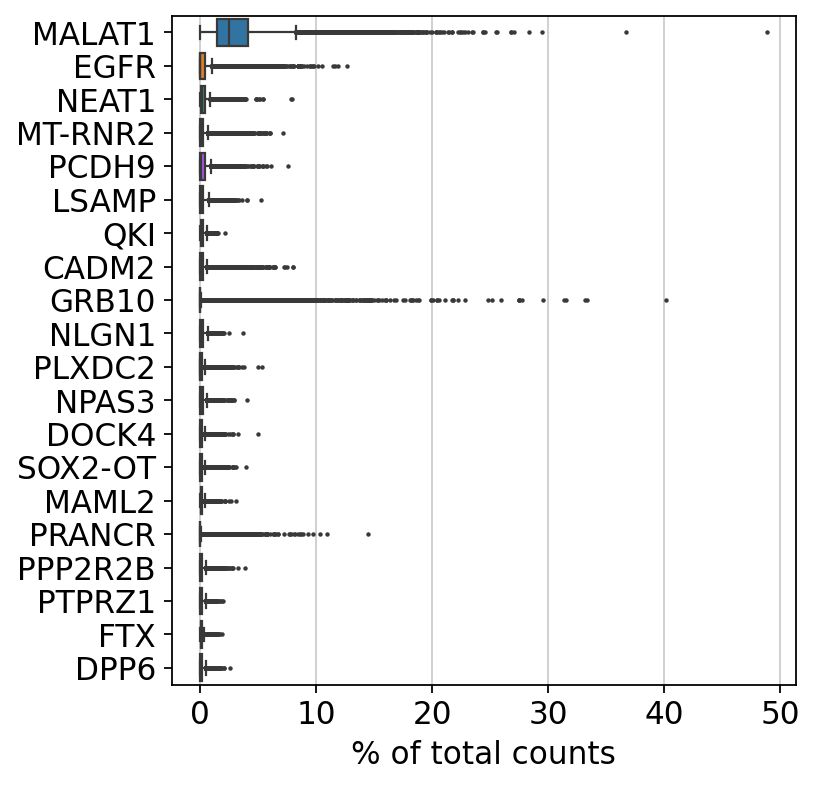

In [15]:
## Plot the highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=plot_high_expression_gene_nr, save='highest_gene_expression.pdf')

# Reference mapping to atlas

In [16]:
adata_ref = ad.read_h5ad('/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/GBmap_core.h5ad')
adata_ref

AnnData object with n_obs × n_vars = 338564 × 27632
    obs: 'author', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'stage', 'location', 'sector', 'sample', 'celltype_original', 'iCNV', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'KI_67', 'chr1p19q', 'PDGFR', 'suspension_type', 'donor_id', 'annotation_level_3', 'annotation_level_4', 'annotation_level_2', 'annotation_level_1', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_app

In [17]:
adata_ref.var['ensembl'] = adata_ref.var_names
#adata_ref.var
adata_ref.var_names = adata_ref.var['feature_name']
# Convert categorical index to string before making unique
adata_ref.var_names = adata_ref.var_names.astype(str)
adata_ref.var_names_make_unique()
adata_ref.var

# Make sure we use raw counts
print(adata_ref.X.max())
print(adata_ref.layers['scaled'].max())
print(adata_ref.raw.X.max())

adata_ref.layers['normalized'] = adata_ref.X.copy()
adata_ref.X = adata_ref.raw.X.copy()

# save adata_ref
adata_ref.write('/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/GBmap_core_scvitools.h5ad')

/apps/gent/RHEL9/cascadelake-ib/software/anndata/0.10.5.post1-foss-2023a/lib/python3.11/site-packages/anndata/_core/anndata.py:956: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ZNF470-DT', 'ENSG00000230393', 'ZNF367', 'SULT1B1', 'TRIM63']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


8.270427
581.86084
216739.0


In [18]:
adata_ref.obs['annotation_level_3'].value_counts()

annotation_level_3
TAM-BDM            61134
TAM-MG             54722
CD4/CD8            54257
AC-like            50847
MES-like           33167
NPC-like           22117
OPC-like           21390
Mono               14215
Oligodendrocyte    12481
DC                  3961
RG                  2807
NK                  2489
Mural cell          1418
B cell              1250
Endothelial          673
Plasma B             572
OPC                  496
Mast                 373
Astrocyte            173
Neuron                22
Name: count, dtype: int64

In [19]:
os.getcwd()

'/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell'

In [22]:
adata_ref.var_names

Index(['ZNF470-DT', 'ENSG00000230393', 'ZNF367', 'SULT1B1', 'TRIM63',
       'PABPN1P1', 'HDHD2', 'MORF4L2-AS1', 'AJUBA-DT', 'TMEM53',
       ...
       'TCP10L3', 'DUSP29', 'LINC02347', 'LINC02096', 'LINC02498', 'LINC02105',
       'LINC02153', 'LINC02546', 'LINC01791', 'LINC02518'],
      dtype='object', name='feature_name', length=27632)

In [23]:
adata_ref = adata_ref.copy()
scvi.model.SCVI.setup_anndata(adata_ref, batch_key="author")

scvi_ref = scvi.model.SCVI(
    adata_ref,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)


In [27]:
# Aggressively clear GPU memory
import gc
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
gc.collect()
        
print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
print("Starting GPU training...")

Memory allocated: 0.00 GB
Memory reserved: 0.00 GB
Starting GPU training...


In [24]:
# Explicitly set accelerator='gpu' and devices=1
scvi_ref.train(accelerator='gpu')

save_dir = '/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/'
scvi_ref.save(save_dir + 'scvi_ref')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 24/24: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [12:10<00:00, 30.15s/it, v_num=1, train_loss_step=7.7e+3, train_loss_epoch=6.75e+3]

`Trainer.fit` stopped: `max_epochs=24` reached.


Epoch 24/24: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [12:10<00:00, 30.46s/it, v_num=1, train_loss_step=7.7e+3, train_loss_epoch=6.75e+3]


ValueError: /kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/scvi_ref already exists. Please provide another directory for saving.

In [25]:
save_dir = '/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/'
scvi_ref.save(save_dir + 'scvi_ref')

In [26]:
# load scvi ref model
save_dir = '/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/'
#scvi_ref = scvi.model.SCVI.load(save_dir + 'scvi_ref', adata_ref)
scvi_ref


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.2, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:44)
running Leiden clustering
    finished: found 57 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:09:10)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:04:20)


/apps/gent/RHEL9/cascadelake-ib/software/scanpy/1.9.8-foss-2023a/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/apps/gent/RHEL9/cascadelake-ib/software/scanpy/1.9.8-foss-2023a/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


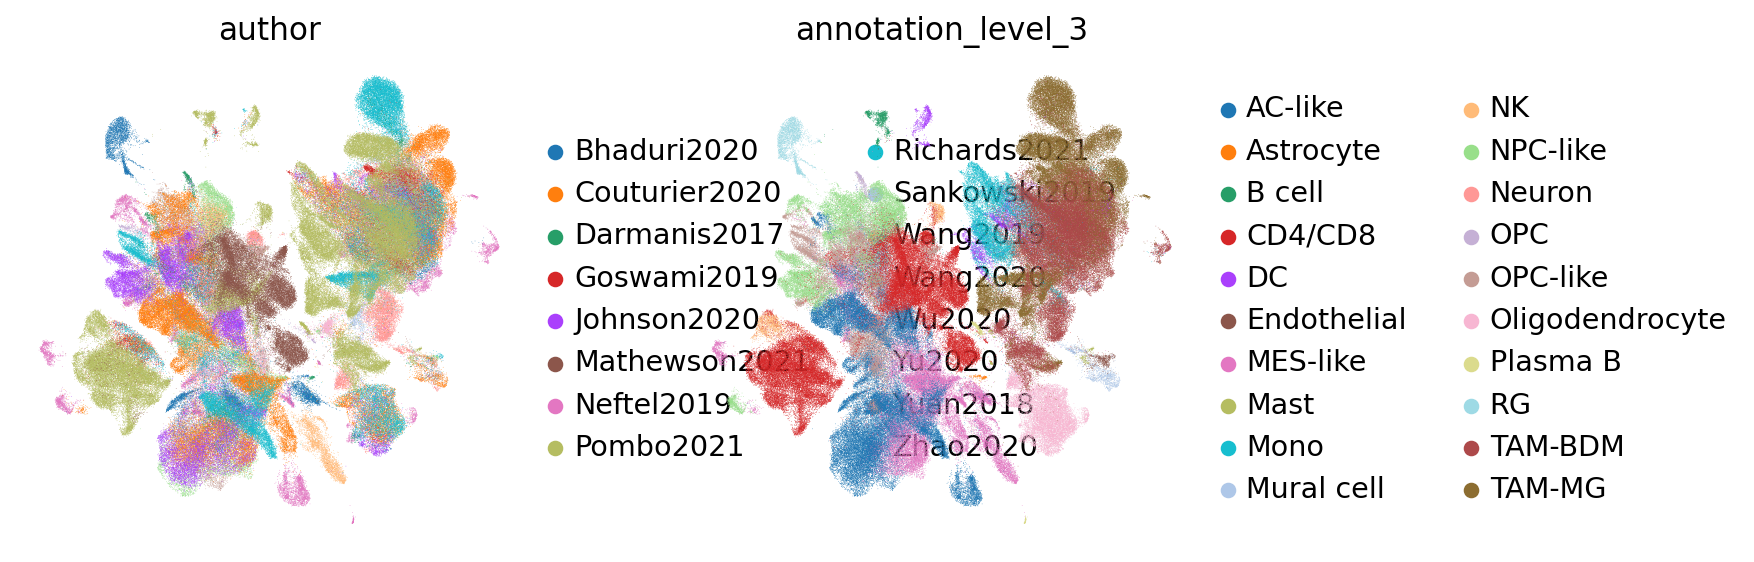

In [27]:
# PLot latent representation
SCVI_LATENT_KEY = "X_scVI"

adata_ref.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

sc.pl.umap(
    adata_ref,
    color=["author", "annotation_level_3"],
    frameon=False,
    ncols=2,
)

## Train scANVI model

In [28]:
condition_key = 'author'
cell_type_key = 'annotation_level_3'
unlabeled = 'unknown'

scanvi_epochs = 100

SCANVI_LABELS_KEY = "labels_scanvi"
adata_ref.obs[SCANVI_LABELS_KEY] = adata_ref.obs["annotation_level_3"].values

save_dir = '/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/'

In [29]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_ref, unlabeled_category="Unknown", labels_key=SCANVI_LABELS_KEY)

print("Labelled Indices: ", len(scanvi_model._labeled_indices))
print("Unlabelled Indices: ", len(scanvi_model._unlabeled_indices))

Labelled Indices:  338564
Unlabelled Indices:  0


In [ ]:
scanvi_model.train(
    max_epochs=100,
    plan_kwargs={
        "weight_decay": 0.01,  # L2 regularization to prevent overfitting
        "lr": 1e-3             # Learning rate
    },
    early_stopping=True,
    check_val_every_n_epoch=10
)

# save model
scanvi_model.save(save_dir + 'scanvi_ref_model')

# save adata_ref with latent and scanvi labels
adata_ref.write('/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/GBmap_core_scvitools.h5ad')

INFO     Training for 150 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performan

Epoch 150/150: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 150/150 [3:34:03<00:00, 85.44s/it, v_num=1, train_loss_step=7.19e+3, train_loss_epoch=6.85e+3]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 150/150 [3:34:03<00:00, 85.63s/it, v_num=1, train_loss_step=7.19e+3, train_loss_epoch=6.85e+3]


In [ ]:
# load scanvi model
# scanvi_model = scvi.model.SCANVI.load(save_dir + 'scanvi_ref_model', adata_ref)

In [31]:
SCANVI_LABELS_KEY = "labels_scanvi"
adata_ref.obs[SCANVI_LABELS_KEY] = adata_ref.obs["annotation_level_3"].values
adata_ref
#adata_ref.layers['norm'] = adata_ref.X # Default layer contains normalized counts
#adata_ref.X = adata_ref.layers['counts'] # raw counts were stored under 'counts'

AnnData object with n_obs × n_vars = 338564 × 27632
    obs: 'author', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'stage', 'location', 'sector', 'sample', 'celltype_original', 'iCNV', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'KI_67', 'chr1p19q', 'PDGFR', 'suspension_type', 'donor_id', 'annotation_level_3', 'annotation_level_4', 'annotation_level_2', 'annotation_level_1', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', '_scvi_batch', '_scvi_labels', 'leiden', 'labels_scanvi'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_

In [41]:
# open saved model
save_dir = '/kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/'

scanvi_ref = scvi.model.SCANVI.load(save_dir + 'scanvi_ref_model', adata=adata_ref)
scanvi_ref

INFO     File                                                                                                      
         /kyukon/scratch/gent/vo/000/gvo00027/projects/CBIGR/25BVM_Lemonite/GBM/data/single_cell/GBmap_core/scanvi_
         ref_model/model.pt already downloaded                                                                     


ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.2, dispersion: gene, 
gene_likelihood: zinb
Training status: Trained
Model's adata is minified?: False

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:31)
running Leiden clustering
    finished: found 60 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:08:18)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:04:26)


/apps/gent/RHEL9/cascadelake-ib/software/scanpy/1.9.8-foss-2023a/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/apps/gent/RHEL9/cascadelake-ib/software/scanpy/1.9.8-foss-2023a/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


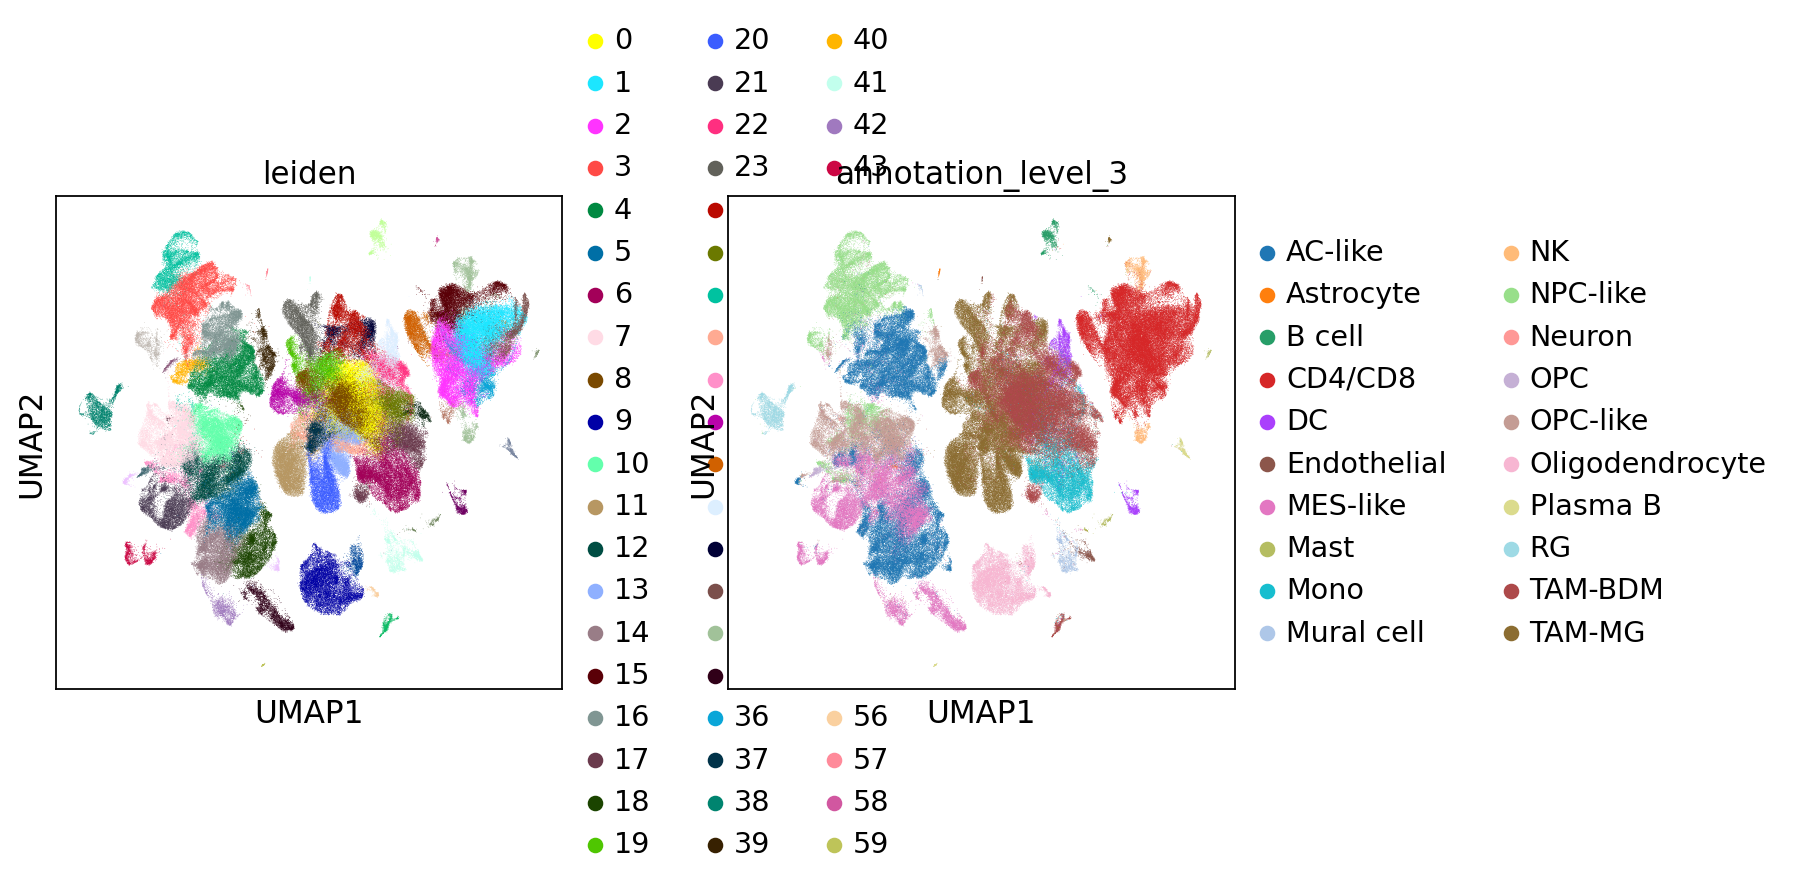

In [34]:
# Have a look at the reference atlas
SCANVI_LATENT_KEY = "X_scANVI"

adata_ref.obsm[SCANVI_LATENT_KEY] = scanvi_ref.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep=SCANVI_LATENT_KEY)
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

sc.pl.umap(adata_ref, color=["leiden", "annotation_level_3"], save='GBmap_scanvi_ref_atlas.pdf')

# Reference mapping

In [ ]:
# Convert categorical var_names to string before making unique
adata_ref.var_names = adata_ref.var_names.astype(str)

# Ensure var_names are unique
adata_ref.var_names_make_unique()

# Also ensure obs_names are unique
adata_ref.obs_names_make_unique()

# Reload the scanvi model with the corrected reference
#scanvi_ref = scvi.model.SCANVI.load(save_dir + 'scanvi_ref_model', adata=adata_ref)

# Make query var_names AND obs_names unique
adata.var_names = adata.var_names.astype(str)
adata.var_names_make_unique()
adata.obs_names_make_unique()

# Check for duplicates before proceeding
print(f"Query has duplicate var_names: {adata.var_names.duplicated().any()}")
print(f"Query has duplicate obs_names: {adata.obs_names.duplicated().any()}")
print(f"Reference has duplicate var_names: {adata_ref.var_names.duplicated().any()}")
print(f"Reference has duplicate obs_names: {adata_ref.obs_names.duplicated().any()}")

# Now prepare query data - this should work now
scvi.model.SCANVI.prepare_query_anndata(adata, scanvi_ref)

# Verify alignment
print(f"Number of genes in query dataset: {adata.n_vars}")
print(f"Number of genes in reference dataset: {adata_ref.n_vars}")

# Check for gene overlap
shared_genes = set(adata.var_names) & set(adata_ref.var_names)
print(f"Number of shared genes: {len(shared_genes)}")
print(f"Percentage overlap: {len(shared_genes)/adata_ref.n_vars*100:.1f}%")

Query has duplicate var_names: False
Query has duplicate obs_names: False
Reference has duplicate var_names: False
Reference has duplicate obs_names: False
INFO     Found 75.832368268674% reference vars in query data.                                                      


/tmp/ipykernel_2202278/1351616211.py:25: UserWarning: Query data contains less than 80% of reference var names. This may result in poor performance.
  scvi.model.SCANVI.prepare_query_anndata(adata, scanvi_ref)


Number of genes in query dataset: 27632
Number of genes in reference dataset: 27632
Number of shared genes: 27632
Percentage overlap: 100.0%


In [22]:
# Add batch ID (author) to adata
adata.obs['author'] = 'query_dataset'

# Train the query model using scArches approach
scanvi_query = scvi.model.SCANVI.load_query_data(
    adata,
    scanvi_ref
)

scanvi_query.train(
    max_epochs=100,
    plan_kwargs={"weight_decay": 0.0},
    check_val_every_n_epoch=10,
    early_stopping=True
)

# Get predictions
SCANVI_PREDICTIONS_KEY = "predictions_scanvi"
SCANVI_LATENT_KEY = "X_scANVI"

adata.obsm[SCANVI_LATENT_KEY] = scanvi_query.get_latent_representation()
adata.obs[SCANVI_PREDICTIONS_KEY] = scanvi_query.predict()

# View predictions
print(adata.obs[SCANVI_PREDICTIONS_KEY].value_counts())

# Save the results
adata.write(result_folder + '/hd5/All_samples_scANVI_annotated.h5ad')
scanvi_query.save(save_dir + 'scanvi_query_model')

/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/scvi/data/_manager.py:209: UserWarning: Missing labels key labels_scanvi. Filling in with unlabeled category Unknown.
  field_registry[_constants._STATE_REGISTRY_KEY] = field.transfer_field(


INFO     Training for 100 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/apps/gent/RHEL9/cascadelake-volta-ib/software/scvi-tools/1.1.2-foss-2023a-CUDA-12.1.1/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performan

Epoch 100/100: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [18:19<00:00, 10.95s/it, v_num=1, train_loss_step=5.97e+3, train_loss_epoch=6.54e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [18:19<00:00, 10.99s/it, v_num=1, train_loss_step=5.97e+3, train_loss_epoch=6.54e+3]
predictions_scanvi
AC-like            10834
TAM-BDM             7453
NPC-like            5615
MES-like            5178
OPC-like            4968
Oligodendrocyte     4746
TAM-MG              3199
CD4/CD8             1821
OPC                  392
Mono                 303
Mural cell           212
DC                   205
NK                   120
Endothelial           98
B cell                42
Plasma B              31
Mast                  17
Astrocyte             11
Name: count, dtype: int64


In [23]:
predicted_annotation = pd.DataFrame(adata.obs[SCANVI_PREDICTIONS_KEY], columns=["predictions_scanvi"])
print(predicted_annotation)

                   predictions_scanvi
AAACCCAAGAATGTTG-1           OPC-like
AAACCCAAGCCACTCG-1            AC-like
AAACCCACATCGAACT-1           MES-like
AAACCCACATCGGTTA-1            CD4/CD8
AAACCCAGTCCTGTTC-1            TAM-BDM
...                               ...
TTTGTTGAGCATTGTC-1    Oligodendrocyte
TTTGTTGCAGACACAG-1             TAM-MG
TTTGTTGTCCCTCGAT-1            AC-like
TTTGTTGTCCGATTAG-1           OPC-like
TTTGTTGTCTCCGTGT-1    Oligodendrocyte

[45245 rows x 1 columns]


In [24]:
# remove cells for which cell type occurs < 50 times 
cells_to_remove = []
for cell_type, count in predicted_annotation['predictions_scanvi'].value_counts().items():
    if count < 50:
        cells_to_remove.extend(predicted_annotation[predicted_annotation['predictions_scanvi'] == cell_type].index.tolist())
adata_filtered = adata[~adata.obs_names.isin(cells_to_remove)].copy()
print(f"Original number of cells: {adata.n_obs}")
print(f"Filtered number of cells: {adata_filtered.n_obs}")

Original number of cells: 45245
Filtered number of cells: 45144


In [25]:
# Merge TAM-BDM and TAM-MG
adata_filtered.obs['predictions_scanvi'] = adata_filtered.obs['predictions_scanvi'].replace({'TAM-BDM': 'TAM', 'TAM-MG': 'TAM'})
adata_filtered

AnnData object with n_obs × n_vars = 45144 × 27632
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt', 'sample_id', 'author', '_scvi_batch', 'labels_scanvi', '_scvi_labels', 'predictions_scanvi'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mt'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_scANVI'

In [26]:
result_folder

'/user/gent/435/vsc43501/25BVM_Lemonite/GBM/data/single_cell/'

In [27]:
# save adata object
adata_filtered.write(result_folder + 'All_samples_scANVI_annotated.h5ad')